[![Colab Badge](https://img.shields.io/badge/Open_in_Colab-blue?style=for-the-badge)][colab-link] [![Download Badge](https://img.shields.io/badge/Download-grey?style=for-the-badge)][download-link] [![JupyterHub](https://img.shields.io/badge/Jupyter_Hub-orange?style=for-the-badge)][jupyter-link]

[download-link]: https://github.com/nmfs-opensci/nmfshackdays-2026/blob/main/topics/2026-05-01/0_kerchunk_basics_hycom_single_file.ipynb
[colab-link]: https://colab.research.google.com/github/nmfs-opensci/nmfshackdays-2026/blob/main/topics/2026-05-01/0_kerchunk_basics_hycom_single_file.ipynb
[jupyter-link]: https://nmfs-openscapes.2i2c.cloud/hub/user-redirect/lab?fromURL=https://raw.githubusercontent.com/nmfs-opensci/nmfshackdays-2026/main/topics/2026-05-01/0_kerchunk_basics_hycom_single_file.ipynb


This notebook introduces the basic idea behind **kerchunk** using the first HYCOM NetCDF file from Rich Signell's HYCOM kerchunk example. The multi-file workflow comes later.  The goal is to show how one ordinary NetCDF file can be scanned and represented as a **virtual Zarr dataset** without copying the data.

[HYCOM](https://registry.opendata.aws/hycom-gofs-3pt1-reanalysis/): HYbrid Coordinate Ocean Model Global Ocean Forecast System Reanalysis 1994-2015. A global ocean dataset that combines a numerical ocean model with observations (like satellites and Argo floats) to provide a consistent, time-varying estimate of ocean conditions such as temperature, currents, and salinity.

**Zarr vs NetCDF and why Zarr is considered cloud-native**

NetCDF and Zarr both store multidimensional scientific data (arrays with dimensions, coordinates, and metadata), but they differ fundamentally in how the data are physically organized. Traditional NetCDF files are typically stored as a single monolithic binary file, which works well on local disks but can be inefficient in cloud environments where data are accessed over networks.

Zarr, in contrast, stores data as many small, independently addressable chunks organized in a **directory-like** structure. Each chunk can be read directly without scanning the whole dataset. This design makes Zarr "cloud-native" or "cloud-read-optimized" because it aligns with how cloud object storage systems (like S3 or GCS) operate: fast access to individual objects via HTTP requests. As a result, Zarr enables efficient parallel reads, scalable analysis with tools like Dask, and responsive subsetting of large datasets without downloading entire files.

**But kerchunk does not change the file chunk structure**

So chunks still might be big, but still smaller since you can load single variables and in the case of HYCOM, single depths. And you can create multi-file Zarr that you use to make a xarray data cube.

## Big picture

Kerchunk is a tool for creating **reference metadata**.

It does not convert the NetCDF file into Zarr. Instead, it builds a small dictionary that says:

```text
Zarr metadata or chunk key  →  byte range inside the original NetCDF file
```

**That reference dictionary can then be opened by xarray as if it were a Zarr store.**

The original data remain where they are:

```text
HYCOM NetCDF file on public S3
        ↓
kerchunk scans metadata and byte ranges
        ↓
reference dictionary in memory (or written to json or parquet)
        ↓
xarray opens kerchunk dictionary like Zarr
```

This is why kerchunk is often described as making a **virtual dataset**.


## What is special about this HYCOM example?

The HYCOM files in this archive are **NetCDF3 / NetCDF 64-bit offset** files, not NetCDF4/HDF5 files.
That matters because kerchunk has different translators for different file formats.

For NetCDF4/HDF5 files, many examples use:

```python
kerchunk.hdf.SingleHdf5ToZarr
```

For this HYCOM example, we use:

```python
kerchunk.netCDF3.NetCDF3ToZarr
```

The output idea is the same: create a reference mapping that lets xarray treat the original NetCDF file like a Zarr dataset.


## Imports

We import:

- `fsspec` to access cloud object storage
- `NetCDF3ToZarr` to scan a NetCDF3 file and create kerchunk references
- `subchunk` to create smaller virtual chunks for large uncompressed arrays
- `xarray` to open the reference mapping as a dataset


In [1]:
import fsspec
import xarray as xr

from kerchunk.netCDF3 import NetCDF3ToZarr
from kerchunk.utils import subchunk

## Connect to the public HYCOM S3 bucket

The source NetCDF files are stored in a public S3 bucket. Because the bucket is public, we use anonymous access: `anon=True`. This tells `s3fs` / `fsspec` not to look for AWS credentials.


In [2]:
fs = fsspec.filesystem("s3", anon=True)

## Find the HYCOM NetCDF files

We will list all files in the S3 `hycom-gofs-3pt1-reanalysis` bucket, but for this basics lesson we will only use the first file. 

1. **Single-file kerchunking**: make one NetCDF file look like Zarr
2. **Multi-file kerchunking**: combine many single-file references along time

This notebook focuses only on the first idea.

In [3]:
flist = fs.glob("hycom-gofs-3pt1-reanalysis/*/*.nc")

len(flist), flist[0]

(63341,
 'hycom-gofs-3pt1-reanalysis/1994/hycom_GLBv0.08_530_1994010112_t000.nc')

## Create references for one NetCDF file

This is the core kerchunk step.

```python
NetCDF3ToZarr(...).translate()
```

1. Kerchunk opens the NetCDF file remotely.
2. It reads the NetCDF metadata.
3. It identifies where variables and array data are located in the file.
4. It builds a reference dictionary that describes the file as a Zarr-like store.

The important point is that this does **not** copy the HYCOM data.

The resulting object, `d0`, is a Python dictionary containing references.

### Why `inline_threshold=400`?

Small pieces of metadata can be embedded directly in the reference dictionary. Larger byte ranges remain as references to the original file. This reduces the number of tiny remote reads needed later.

### Why `version=2`?

This asks kerchunk to produce a reference mapping compatible with Zarr version 2.


In [4]:
%%time

first_file = "s3://" + flist[0]

# Create kerchunk references for one HYCOM NetCDF file.
d0 = NetCDF3ToZarr(
    first_file,
    storage_options={"anon": True},
    inline_threshold=400,
    version=2,
).translate()

CPU times: user 361 ms, sys: 96.4 ms, total: 457 ms
Wall time: 2.32 s


## Inspect the reference dictionary

The reference dictionary is the virtual Zarr store. It contains entries for things like:

- `.zgroup`
- `.zattrs`
- variable metadata such as `water_temp/.zarray`
- chunk references such as `water_temp/0.0.0.0`

Some entries are metadata stored directly in the dictionary. Others point to byte ranges in the original NetCDF file.


In [5]:
type(d0), list(d0.keys())[:10]

(dict, ['version', 'refs'])

In [6]:
# Show a few reference keys.
list(d0["refs"].keys())[:20]

['lat/0',
 'lon/0',
 'water_u/0.0.0.0',
 'water_u_bottom/0.0.0',
 'water_v/0.0.0.0',
 'water_v_bottom/0.0.0',
 'water_temp/0.0.0.0',
 'water_temp_bottom/0.0.0',
 'salinity/0.0.0.0',
 'salinity_bottom/0.0.0',
 'surf_el/0.0.0',
 '.zgroup',
 '.zattrs',
 'lat/.zarray',
 'lat/.zattrs',
 'lon/.zarray',
 'lon/.zattrs',
 'water_u/.zarray',
 'water_u/.zattrs',
 'water_u_bottom/.zarray']

In [7]:
d0["refs"]['water_u/0.0.0.0']

['s3://hycom-gofs-3pt1-reanalysis/1994/hycom_GLBv0.08_530_1994010112_t000.nc',
 66984,
 1170360000]

## Subchunk the large 4D (time/lat/lon/depth) variables

The HYCOM NetCDF files are uncompressed and not chunked like cloud-native Zarr.

Kerchunk can create **virtual chunks** by splitting large arrays into smaller byte-range references. In Rich's notebook this is done with `subchunk`. Here the 4D variables are: salinity, water_temp, water_u, water_v.

```python
subchunk(store=d0, variable=v, factor=40)
```

splits each variable along the vertical dimension so that each vertical layer can be treated more like a chunk. Without subchunking, reading a single depth layer might require reading a much larger block than needed.

In [8]:
for v in ["salinity", "water_temp", "water_u", "water_v"]:
    d0 = subchunk(store=d0, variable=v, factor=40)

nb. It does change the layout of the dictionary, moving `refs` key to base.

In [9]:
type(d0), list(d0.keys())[:10]

(dict,
 ['lat/0',
  'lon/0',
  'water_u/0.0.0.0',
  'water_u_bottom/0.0.0',
  'water_v/0.0.0.0',
  'water_v_bottom/0.0.0',
  'water_temp/0.0.0.0',
  'water_temp_bottom/0.0.0',
  'salinity/0.0.0.0',
  'salinity_bottom/0.0.0'])

## Open the kerchunk references with xarray

Now we open the reference dictionary as a dataset using `engine="kerchunk"`. Notice that `d0` is not a filename here. It is the reference dictionary in memory.

`engine="kerchunk"` tells xarray to use kerchunk's backend, and:

```python
remote_protocol="s3"
remote_options={"anon": True}
```

tell kerchunk how to read the original HYCOM NetCDF file. The original file is still on S3. Kerchunk only provides the map that tells xarray which byte ranges to read.


In [10]:
# tell it that the HYCOM S3 bucket is public
so = dict(anon=True, skip_instance_cache=True)

single = xr.open_dataset(
    d0,
    engine="kerchunk",
    chunks={},
    drop_variables="tau",
    backend_kwargs=dict(
        storage_options=dict(
            remote_protocol="s3",
            lazy=False,
            remote_options=so,
        )
    ),
)

single


<xarray.Dataset> Size: 19GB
Dimensions:            (time: 1, depth: 40, lat: 3251, lon: 4500)
Coordinates:
  * time               (time) datetime64[ns] 8B 1994-01-01T12:00:00
  * depth              (depth) float64 320B 0.0 2.0 4.0 ... 3e+03 4e+03 5e+03
  * lat                (lat) float64 26kB -80.0 -79.96 -79.92 ... 89.96 90.0
  * lon                (lon) float64 36kB -180.0 -179.9 -179.8 ... 179.8 179.9
Data variables:
    water_u            (time, depth, lat, lon) float64 5GB dask.array<chunksize=(1, 1, 3251, 4500), meta=np.ndarray>
    water_u_bottom     (time, lat, lon) float64 117MB dask.array<chunksize=(1, 3251, 4500), meta=np.ndarray>
    water_v            (time, depth, lat, lon) float64 5GB dask.array<chunksize=(1, 1, 3251, 4500), meta=np.ndarray>
    water_v_bottom     (time, lat, lon) float64 117MB dask.array<chunksize=(1, 3251, 4500), meta=np.ndarray>
    water_temp         (time, depth, lat, lon) float64 5GB dask.array<chunksize=(1, 1, 3251, 4500), meta=np.ndarray>
    water_temp_bottom  (time, lat, lon) float64 117MB dask.array<chunksize=(1, 3251, 4500), meta=np.ndarray>
    salinity           (time, depth, lat, lon) float64 5GB dask.array<chunksize=(1, 1, 3251, 4500), meta=np.ndarray>
    salinity_bottom    (time, lat, lon) float64 117MB dask.array<chunksize=(1, 3251, 4500), meta=np.ndarray>
    surf_el            (time, lat, lon) float64 117MB dask.array<chunksize=(1, 3251, 4500), meta=np.ndarray>
Attributes:
    classification_level:      UNCLASSIFIED
    distribution_statement:    Approved for public release. Distribution unli...
    downgrade_date:            not applicable
    classification_authority:  not applicable
    institution:               Naval Oceanographic Office
    source:                    HYCOM archive file
    history:                   archv2ncdf3z
    field_type:                instantaneous
    Conventions:               CF-1.6 NAVO_netcdf_v1.1

In [11]:
single.chunks

Frozen({'time': (1,), 'depth': (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1), 'lat': (3251,), 'lon': (4500,)})

In [12]:
# each time slice is 19 GB
single.nbytes / 1e9

19.311002336

## What did we get?

We now have an xarray `Dataset` that behaves like it was opened from a Zarr store, but the physical data were not converted to Zarr.

Instead:

```text
xarray request
    ↓
kerchunk reference mapping
    ↓
byte ranges in the original NetCDF file
    ↓
array returned to xarray
```


## Read a small subset

Kerchunk is most useful when we read only the pieces of data we need. Here we select a small spatial window from one variable. This should read a small amount of data from the remote NetCDF file rather than downloading the full file.

In [13]:
subset = single["water_temp"].isel(
    time=0,
    depth=0,
    lat=slice(1000, 1020),
    lon=slice(1000, 1020),
)

subset


<xarray.DataArray 'water_temp' (lat: 20, lon: 20)> Size: 3kB
dask.array<getitem, shape=(20, 20), dtype=float64, chunksize=(20, 20), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 160B -40.0 -39.92 -39.84 ... -38.64 -38.56 -38.48
  * lon      (lon) float64 160B -100.0 -99.92 -99.84 ... -98.64 -98.56 -98.48
    depth    float64 8B 0.0
    time     datetime64[ns] 8B 1994-01-01T12:00:00
Attributes:
    long_name:      Water Temperature
    standard_name:  sea_water_temperature
    units:          degC
    NAVO_code:      15
    comment:        in-situ temperature

## Plot the small subset

The previous cell creates a lazy xarray object. The actual data are read when we call `.load()`, `.compute()`, or make a plot.

```text
creating the xarray object ≠ reading all the data
```

Only the requested subset will be read BUT we have to read full chunks so ~117 MB of temporary memory will be used to read the chunk and then it will be discarded.

In [14]:
single.water_temp.isel(depth=0).nbytes / 1e6

117.036

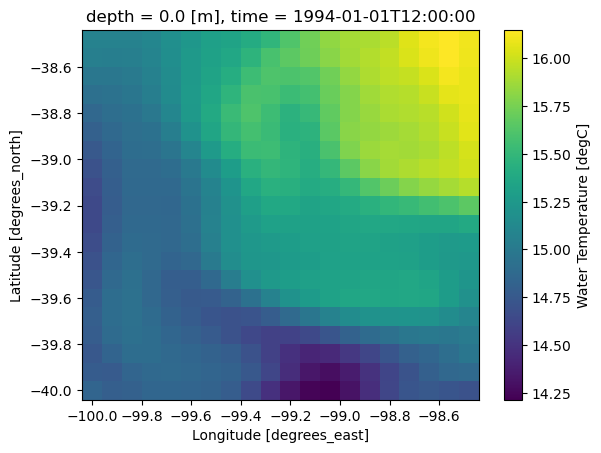

In [14]:
subset.plot()

## Recap

This example teaches the basic unit of kerchunking:

```text
one NetCDF file → one reference mapping
```

The full HYCOM workflow then repeats or adapts this idea across many files.

In Rich's larger notebook, the first file is used to define the schema because all HYCOM files have the same structure:

- same variables
- same grid
- same dimensions
- different time values

The multi-file workflow combines many references along the time dimension to create one virtual dataset.

Rich's larger workflow produces a Parquet reference store (`hycom.parq`) because the combined references are too large for a convenient single JSON file.


## Summary

In this notebook we:

1. Found the public HYCOM NetCDF files on S3
2. Selected the first file
3. Used `NetCDF3ToZarr` to create kerchunk references
4. Subchunked large 4D variables for more useful access patterns
5. Opened the references with xarray
6. Read a small subset without converting or downloading the full dataset

The key lesson is:

> Kerchunk turns existing files into virtual Zarr-like datasets by creating references, not by copying data.
